# Data Exploration

**Goal**: Understand the raw data, assess quality, perform necessary cleaning, and get first business insights.

**Dataset**: Online Retail (UCI/Kaggle) – ~542k giftware transactions (UK online retailer, 2010–2011)

In [83]:
# 0. Import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
import warnings
warnings.filterwarnings('ignore')

## 1. Read data

In [86]:
# 1. Load the data
df = pd.read_excel('../data/online-retail.xlsx')
print(df.shape[0], df.shape[1])

# Print the data
print(df.head())

541909 8
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


## 2. Overview

In [88]:
# Info
df.info()

# Basic statistics
df.describe()

# Missing values
print(df.isna().sum())
print("\nMissing CustomerID percentage: {:.1f}%".format(
    df['CustomerID'].isna().mean() * 100))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing CustomerID percentage: 24.9%


## 3. Quality checks

In [90]:
# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

print("\nNegative / zero quantities:", (df['Quantity'] <= 0).sum())
print("Negative / zero unit prices :", (df['UnitPrice'] <= 0).sum())

print("\nInvoices that look like cancellations:", 
      df['InvoiceNo'].astype(str).str.startswith('C').sum())

print("\nUnique customers:", df['CustomerID'].nunique())
print("Unique products (StockCode):", df['StockCode'].nunique())
print("Unique descriptions:", df['Description'].nunique())


Duplicate rows: 5268

Negative / zero quantities: 10624
Negative / zero unit prices : 2517

Invoices that look like cancellations: 9288

Unique customers: 4372
Unique products (StockCode): 4070
Unique descriptions: 4223


## 4. Data Cleaning

In [101]:
df_clean = df.copy()

# Remove cancellations
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Remove rows with missing CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])

# Keep only positive quantities and price
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

print("Original shape:   ", df.shape)
print("After cleaning:   ", df_clean.shape)
print("Rows kept:        {:.1f}%".format(len(df_clean)/len(df)*100))

Original shape:    (541909, 8)
After cleaning:    (397884, 8)
Rows kept:        73.4%


## 5. Create columns

In [107]:
df_clean['Revenue']     = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

df_clean['yearmonth']   = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['date']        = df_clean['InvoiceDate'].dt.date
df_clean['dayofweek']   = df_clean['InvoiceDate'].dt.day_name()
df_clean['hour']        = df_clean['InvoiceDate'].dt.hour

df_clean.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,yearmonth,date,dayofweek,hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12-01,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12-01,Wednesday,8


## 6. Business views plots

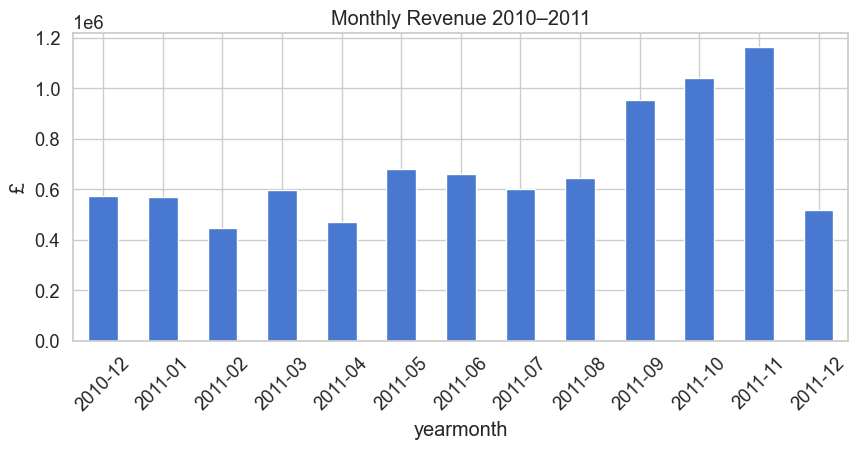

In [111]:
# Revenue per month
df_clean.groupby('yearmonth')['Revenue'].sum().plot(kind='bar', figsize=(10,4))
plt.title('Monthly Revenue 2010–2011')
plt.ylabel('£')
plt.xticks(rotation=45)
plt.show()

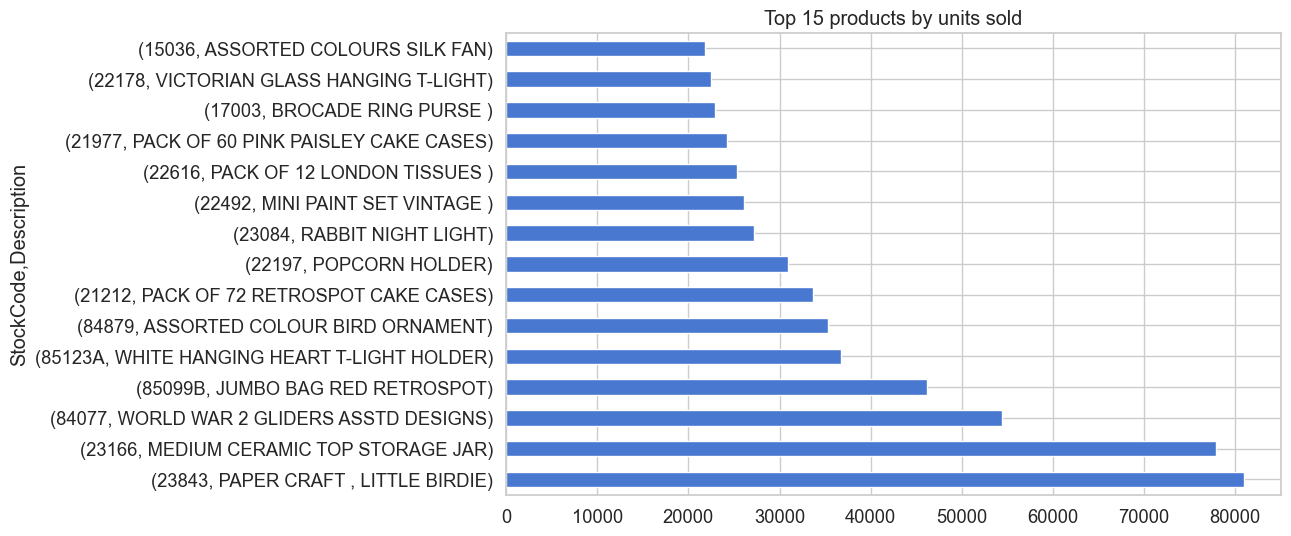

In [113]:
# Top 15 products by quantity sold
top_prod = df_clean.groupby(['StockCode','Description'])['Quantity'].sum()\
           .sort_values(ascending=False).head(15)

top_prod.plot(kind='barh', figsize=(10,6))
plt.title('Top 15 products by units sold')
plt.show()

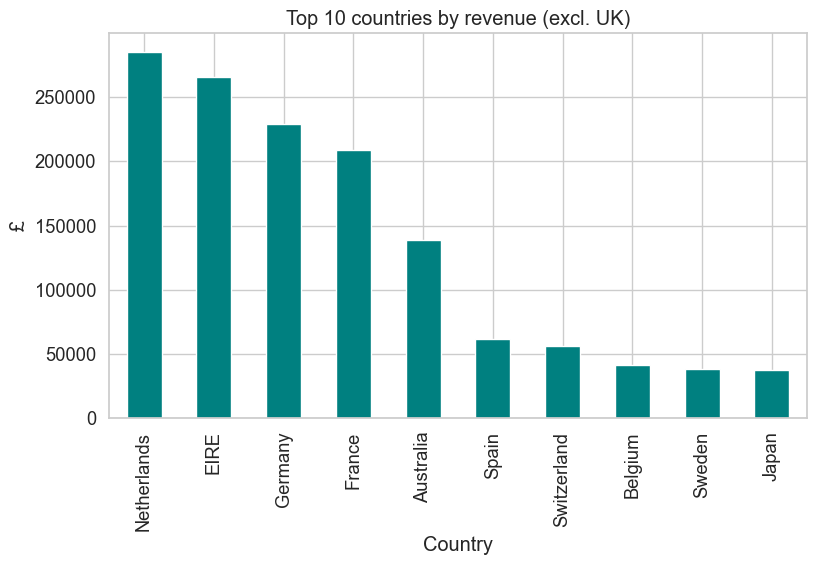

In [115]:
# Top 10 countries by revenue (excluding UK)
(df_clean[df_clean['Country'] != 'United Kingdom']
 .groupby('Country')['Revenue'].sum()
 .sort_values(ascending=False)
 .head(10)
 .plot(kind='bar', figsize=(9,5), color='teal'))
plt.title('Top 10 countries by revenue (excl. UK)')
plt.ylabel('£')
plt.show()

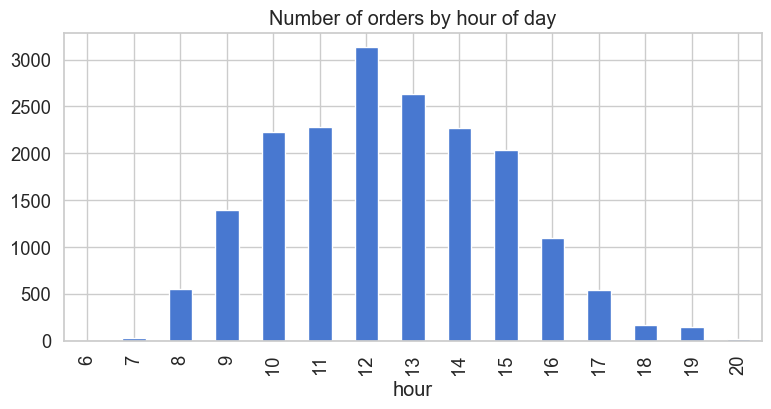

In [117]:
# Orders by hour of day
df_clean.groupby('hour')['InvoiceNo'].nunique().plot(kind='bar', figsize=(9,4))
plt.title('Number of orders by hour of day')
plt.show()

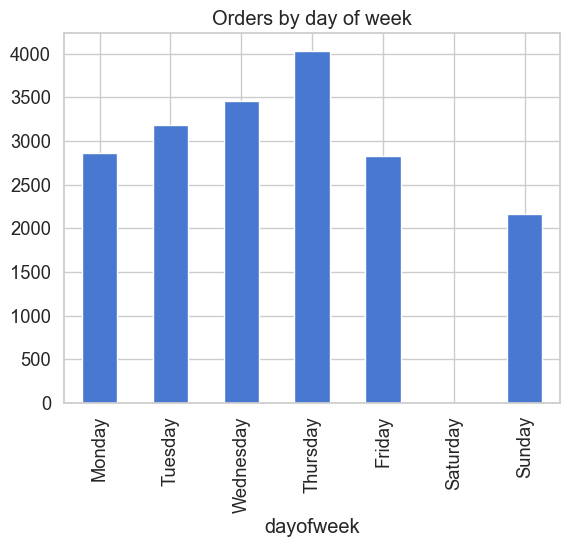

In [119]:
# Orders by day of week
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df_clean.groupby('dayofweek')['InvoiceNo'].nunique().reindex(order).plot(kind='bar')
plt.title('Orders by day of week')
plt.show()

## 7. Final checkpoints

In [122]:
print("Final clean dataset shape:", df_clean.shape)
print("Unique customers:     ", df_clean['CustomerID'].nunique())
print("Unique invoices:      ", df_clean['InvoiceNo'].nunique())
print("Total revenue:       £{:,.0f}".format(df_clean['Revenue'].sum()))
print("Date range:          ", df_clean['date'].min(), "–", df_clean['date'].max())

Final clean dataset shape: (397884, 13)
Unique customers:      4338
Unique invoices:       18532
Total revenue:       £8,911,408
Date range:           2010-12-01 – 2011-12-09


## 8. Future sections

In [125]:
# Distribution of order values per invoice
# Items per invoice distribution
# Top customers by monetary value

In [130]:
# Save cleaned dataset
# Save as CSV
df_clean.to_csv('../data/online-retail-cleaned.csv', index=False)